In [1]:
# using Pkg; Pkg.update("TuLiPa") # uncomment to update TuLiPa to latest version
using DataFrames, Plots, Statistics, JSON, Clp, TuLiPa, Dates, CSV, JuMP, HiGHS
#plotlyjs() # uncomment for interactive plots
include("../test/fixtures/dummy_data.jl"); # Hid some functions here to make the notebook more readable

# Demo 1a - Deterministic power market with dummy data

We show how you can set up a simple deterministic power market problem with TuLiPa. The problem will minimize the cost of covering the demand with production from different technologies.

The problem contains:

- Two price areas: NO2 and GER (€/GWh)
- Transmission between the areas
- Inelastic demand in both areas
- Wind and solar in both areas
- Two hydropower plants in NO2 (one reservoir and one run-of-river)
- Four thermal plants in GER (gas, coal, biogas and nuclear)
- Two commodities: Power (GWh and MW) and Hydro (Mm3 and m3/s) 
- Two horizons / time-resolutions: The market balance (power commodity) with daily resolution. The waterbalance (hydro commodity) is weekly. The assumption here is that the waterbalances do not need a very fine time-resolution, so we take advantage of TuLiPa supporting different horizons in the same problem. This gives a smaller problem with less balances and variables.
- Different input data for different scenarios: Constants or time-series data for different weather scenarios and model years.

These elements need their own model objects. Each model object (e.g. hydropower production or the water balance) has an id, horizon (with time resolution) and special properties. The properties of the object contain information about which elements must be built and updated in the LP problem, as well as a dataset. The dataset can contain values for different weather scenarios, and different model years (e.g. installed capacity in 2021 or 2025). When we update the problem with a weather scenario (scenario time) and a model year (data time), the model objects will build the LP problem for this input data. Then the problem can be solved.

In this demo we use dummy data, and profiles for wind, solar, demand and inflow from https://www.nve.no/energi/analyser-og-statistikk/vaerdatasett-for-kraftsystemmodellene/

## Overview of the document:
### 1 - Make a dataset
### 2 - Build, update and solve a problem
### 3 - Run several scenarios and look at results

# 1 - Make dataset

### DataElements

The model objects are assembled from a list of dataelements. The dataelements have a concept, concepttype, unique instancename and a data field. The conceptname and concepttype decide how the dataelement should be converted to a model object, while the data field holds all the data that should be put into the model object.

The data elements are stored in a flat structure where each data element holds its information and possibly references to other dataelements they are linked to (for example can an upper capacity hold references to its parameter (stored in another data element), and references to the variable this upper capacity should apply to).

### Helping functions to define a dataset of DataElements

In [2]:
# We have hid these functions in the file Demo 1a - Deterministic power market with dummy data.jl
# Alternatively take a look at Demo 1b where all the code is included in the notebook
elements = gettestdataset();

### Take a look at the dataelements

In [27]:
println(string("Number of elements: ", length(elements)))
first(elements, 10) # print first 10 elements
# elements # print all elements

Number of elements: 112


10-element Vector{DataElement}:
 DataElement("Balance", "BaseBalance", "PowerBalance_NO2", Dict{Any, Any}("Commodity" => "Power"))
 DataElement("Flow", "BaseFlow", "SlackVarPowerBalance_NO2", Dict{Any, Any}())
 DataElement("Arrow", "BaseArrow", "SlackArrowPowerBalance_NO2", Dict{Any, Any}("Balance" => "PowerBalance_NO2", "Flow" => "SlackVarPowerBalance_NO2", "Conversion" => 1.0, "Direction" => "Out"))
 DataElement("Balance", "BaseBalance", "PowerBalance_GER", Dict{Any, Any}("Commodity" => "Power"))
 DataElement("Flow", "BaseFlow", "SlackVarPowerBalance_GER", Dict{Any, Any}())
 DataElement("Arrow", "BaseArrow", "SlackArrowPowerBalance_GER", Dict{Any, Any}("Balance" => "PowerBalance_GER", "Flow" => "SlackVarPowerBalance_GER", "Conversion" => 1.0, "Direction" => "Out"))
 DataElement("Flow", "BaseFlow", "PowerBalance_NO2->PowerBalance_GER", Dict{Any, Any}())
 DataElement("Arrow", "BaseArrow", "PowerBalance_NO2->PowerBalance_GERFrom", Dict{Any, Any}("Balance" => "PowerBalance_NO2", "Flow" =

### Runsettings

Define some model settings that completes the dataset.

In [4]:
# Select the weather scenarios 1981-1982 (some of the profiles are 1981-2010, we only want to use two years)
# Used by RotatingTimeVector to reduce the amount of data
scenarioyearstart = 1981
scenarioyearstop = 1983
addscenariotimeperiod!(elements, "ScenarioTimePeriod", getisoyearstart(scenarioyearstart), getisoyearstart(scenarioyearstop));

In [5]:
# We choose the horizon (time-resolution) of the commodities. We set the duration of the horizons to 3 years
# We want the variables connected to power (daily) to be more detailed than the hydro variables (weekly)
power_horizon = SequentialHorizon(364*3, Day(1))
hydro_horizon = SequentialHorizon(52*3, Week(1))
set_horizon!(elements, "Power", power_horizon)
set_horizon!(elements, "Hydro", hydro_horizon);

In [6]:
# Storages have state-dependant variables that need a boundary condition
# We set the starting storage to be equal to the ending storage, x[0] = x[T] (for horizon where t in 1:T)
push!(elements, getelement(BOUNDARYCONDITION_CONCEPT, "StartEqualStop", "StartEqualStop_StorageResNO2",
        (WHICHINSTANCE, "StorageResNO2"),
        (WHICHCONCEPT, STORAGE_CONCEPT)));

### Make model objects from dataelements

In [7]:
modelobjects = getmodelobjects(elements)

keys(modelobjects)

KeySet for a Dict{Id, Any} with 15 entries. Keys:
  Id("Balance", "PowerBalance_NO2")
  Id("Flow", "PowerBalance_GER->PowerBalance_NO2")
  Id("Balance", "ResNO2")
  Id("Flow", "SlackVarPowerBalance_NO2")
  Id("Flow", "GenGasGER")
  Id("Flow", "SpillResNO2")
  Id("Flow", "SlackVarPowerBalance_GER")
  Id("Flow", "ReleaseResNO2")
  Id("Flow", "GenBioGER")
  Id("BoundaryCondition", "StartEqualStop_StorageResNO2")
  Id("Balance", "PowerBalance_GER")
  Id("Flow", "GenCoalGER")
  Id("Storage", "StorageResNO2")
  Id("Flow", "GenNucGER")
  Id("Flow", "PowerBalance_NO2->PowerBalance_GER")

### Take a look at the hydropower release variable

In [8]:
println("We display the fields in the struct")
display(fieldnames(typeof(modelobjects[Id("Flow", "ReleaseResNO2")])))

println("\nThe Id shows that the struct is of type Flow")
display(getid(modelobjects[Id("Flow", "ReleaseResNO2")]))

println("\nThe Horizon consist of 1092 periods with timedelta of 1 day (total 3 years)")
display(gethorizon(modelobjects[Id("Flow", "ReleaseResNO2")]))

println("\nThe lower bound is LowerZeroCapacity so that the variable is non-negative")
display(getlb(modelobjects[Id("Flow", "ReleaseResNO2")]))

println("\nThe upper bound is 6000 m3/s, which is stored in a M3SToMM3SeriesParam. M3SToMM3SeriesParam converts the upper bound into Mm3 depending on the horizon of the problem")
display(getub(modelobjects[Id("Flow", "ReleaseResNO2")]))

println("\nThere are two arrows. The first says that the release takes water out from the water balance and the second says that it contributes into the power balance")
for arrow in getarrows(modelobjects[Id("Flow", "ReleaseResNO2")])
    display(getid(arrow))
#     display(arrow)
end

(:id, :horizon, :ub, :lb, :costs, :sumcost, :arrows, :metadata)

We display the fields in the struct

The Id shows that the struct is of type Flow

The Horizon consist of 1092 periods with timedelta of 1 day (total 3 years)

The lower bound is LowerZeroCapacity so that the variable is non-negative

The upper bound is 6000 m3/s, which is stored in a M3SToMM3SeriesParam. M3SToMM3SeriesParam converts the upper bound into Mm3 depending on the horizon of the problem

There are two arrows. The first says that the release takes water out from the water balance and the second says that it contributes into the power balance


Id("Flow", "ReleaseResNO2")

SequentialHorizon(SequentialPeriods([(1092, Millisecond(86400000))]), nothing)

LowerZeroCapacity()

PositiveCapacity(Id("Capacity", "CapReleaseResNO2"), M3SToMM3SeriesParam{ConstantTimeVector, ConstantTimeVector}(ConstantTimeVector(6000.0), ConstantTimeVector(1.0)), true)

Id("Arrow", "WaterDemandReleaseResNO2")

Id("Arrow", "PowerSupplyReleaseResNO2")

### Take a look at the wind parameter for GER

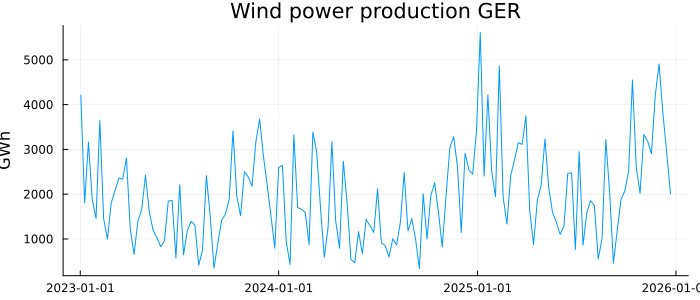

In [9]:
# It is stored in one of the rhsterms of PowerBalance_NO2
rhsterm = getrhsterms(modelobjects[Id("Balance", "PowerBalance_GER")])[1]

# We start with the installed capacity in 2023 and the weather scenario 1981
start = TwoTime(getisoyearstart(2023), getisoyearstart(1981))

# We look at the weekly production in GWh for three years from the starting point
horizon = SequentialHorizon(52*3, Week(1))

# Vectors to store results
i = Vector{typeof(getdatatime(start))}(undef, getnumperiods(horizon))
v = zeros(getnumperiods(horizon))

# Query results for each period in the horizon
for t in 1:getnumperiods(horizon)
    querystart = getstarttime(horizon, t, start)
    querydelta = gettimedelta(horizon, t)
    i[t] = getdatatime(querystart)
    v[t] = getparamvalue(rhsterm, querystart, querydelta)
end

# Plot
display(plot(i, v, legend=false, size=(700,300), ylabel = "GWh", title = "Wind power production GER"))

- In 1.3 we define the installed wind capacity for 2021 and 2025. We therefore see that the wind power production increases in 2025. This is because the level is an InfiniteTimeVector.
- Since we chose in 1.5 to only use the weather years 1981 and 1982, the profile reuses 1981 for the third year. This is because the profile is a RotatingTimeVector

# 2 - Show how a problem can be built, updated and solved

## 2.1 - Initialize a JuMP_Prob problem
We build a problem object for a minimization problem. The problem object consist of:
- A JuMP model with the solver CLP
    - JuMP is a modelling framework for working with optimization problems: https://github.com/jump-dev/JuMP.jl
    - Clp is an open-source LP-solver: https://github.com/jump-dev/Clp.jl
- The list of model objects

The problem is also initialized. Variables and balances are built, and variables are put into balances and the objective function if coefficients are constant regardless of scenario or horizon period.

In [10]:
mymodel = JuMP.Model(Clp.Optimizer)
set_silent(mymodel)

prob = JuMP_Prob(modelobjects, mymodel)
# prob = HiGHS_Prob(modelobjects) # we could also have used HiGHS_Prob, but printing the mathematical model is not supported there

prob.model

A JuMP Model
Minimization problem with:
Variables: 10141
Objective function type: AffExpr
`AffExpr`-in-`MathOptInterface.EqualTo{Float64}`: 2341 constraints
`VariableRef`-in-`MathOptInterface.GreaterThan{Float64}`: 10140 constraints
`VariableRef`-in-`MathOptInterface.LessThan{Float64}`: 7800 constraints
Model mode: AUTOMATIC
CachingOptimizer state: EMPTY_OPTIMIZER
Solver name: Clp
Names registered in the model: BalancePowerBalance_GER, BalancePowerBalance_NO2, BalanceResNO2, BoundaryConditionEqStartEqualStop_StorageResNO2, FlowGenBioGER, FlowGenCoalGER, FlowGenGasGER, FlowGenNucGER, FlowPowerBalance_GER->PowerBalance_NO2, FlowPowerBalance_NO2->PowerBalance_GER, FlowReleaseResNO2, FlowSlackVarPowerBalance_GER, FlowSlackVarPowerBalance_NO2, FlowSpillResNO2, StorageStartStorageResNO2, StorageStorageResNO2

The hydrorbalance has been initialized. But the inflow is not added since the value depends on the chosen scenario and period in the horizon.

In [11]:
display(prob.model[:BalanceResNO2][1])

BalanceResNO2[1] : FlowSpillResNO2[1] + FlowReleaseResNO2[1] + FlowReleaseResNO2[2] + FlowReleaseResNO2[3] + FlowReleaseResNO2[4] + FlowReleaseResNO2[5] + FlowReleaseResNO2[6] + FlowReleaseResNO2[7] + StorageStorageResNO2[1] - StorageStartStorageResNO2[1] == 0

## 2.2 - Choose a starting point for the horizon and update the problem
Variables are now put into balances and the objective function if coefficients are dependant on the scenario or horizon period. 
RHSTerms like the inflow are also updated, but it is stored in the problem object rather than updated in the JuMP model straight away. When solve! is called, the problem object will check if any of the RHSTerm has been updated. If that is the case, the JuMP model will be updated with the RHSTerms.

In [12]:
t = TwoTime(getisoyearstart(2021), getisoyearstart(1981))

update!(prob, t)

## 2.3 - Solve the problem and display the solution

In [13]:
@time solve!(prob)

getobjectivevalue(prob)

  1.542074 seconds (1.09 M allocations: 81.631 MiB, 1.87% gc time, 95.39% compilation time)


9.616463034033792e10

Now the hydropower balance also includes the inflow, which is 156 Mm3 in the second week of the problem.

In [14]:
display(prob.model[:BalanceResNO2][1])

BalanceResNO2[1] : FlowSpillResNO2[1] + FlowReleaseResNO2[1] + FlowReleaseResNO2[2] + FlowReleaseResNO2[3] + FlowReleaseResNO2[4] + FlowReleaseResNO2[5] + FlowReleaseResNO2[6] + FlowReleaseResNO2[7] + StorageStorageResNO2[1] - StorageStartStorageResNO2[1] == 311.2851168

## 2.4 - Update the problem with a start time from another model year and weather scenario, and solve the problem again
- We get a new solution to the problem
- The inflow is now different since we start at the weather scenario 1982 and the inflow level from 2025.

In [15]:
t = TwoTime(getisoyearstart(2024), getisoyearstart(1982))

update!(prob, t)

solve!(prob)

display(getobjectivevalue(prob))

display(prob.model[:BalanceResNO2][1])

8.194441022906747e10

BalanceResNO2[1] : FlowSpillResNO2[1] + FlowReleaseResNO2[1] + FlowReleaseResNO2[2] + FlowReleaseResNO2[3] + FlowReleaseResNO2[4] + FlowReleaseResNO2[5] + FlowReleaseResNO2[6] + FlowReleaseResNO2[7] + StorageStorageResNO2[1] - StorageStartStorageResNO2[1] == 53.7303888

## 2.5 - Look at prices

### Collect daily prices from the model using the JuMP result framework
The prices are in EUR/MWh. The price decline from 2025 is a result of the new gas price level in 2025.

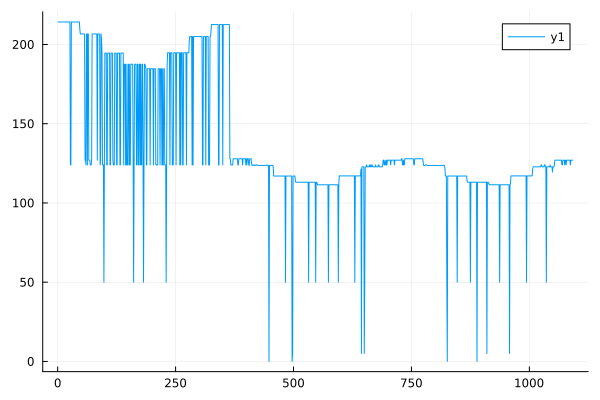

In [16]:
plot(-dual.(prob.model[:BalancePowerBalance_GER])/1000)
# plot(value.(prob.model[:FlowGenGasGER])) # Or we could get the daily gas production in GWh

### Or we could use the result functions built into JuMP_Prob
- getcondual() to get prices
- getvarvalue()
- getrhsterm()

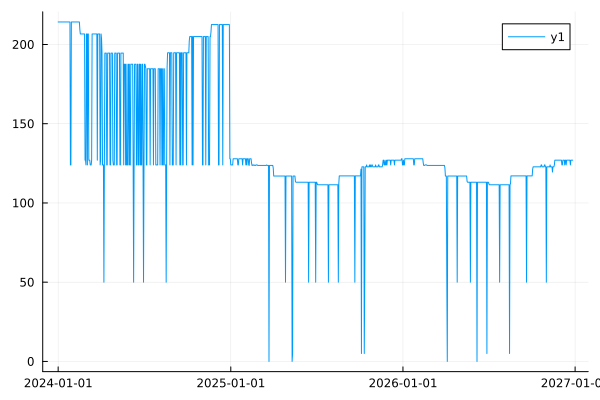

In [17]:
numperiods = getnumperiods(power_horizon)
x = [getdatatime(t) + getstartduration(power_horizon, s) for s in 1:numperiods]
y = [-getcondual(prob, Id("Balance","PowerBalance_GER"), s) for s in 1:numperiods]/1000
plot(x,y)

# 3 - Run several scenarios and look at more results

## 3.1 Function that builds, updates and solves the problem, and plot the results

The function runs several scenarios and plot prices, supplies, demands and hydro storages for each scenario. The function only plots results for chosen price areas.

In Demo 2 a more complex version of this function is used, which support more types of objects. This includes AdaptiveHorizons (horizon built based on residual load), Horizons with offset, SegmentedArrow (for hydropower plants with PQ-curves), BaseAggSupplyCurve (for aggregated power plants) and ExogenBalance (exogen price areas)

In [28]:
# The functions getscenarios and runscenarios are hidden in this demo. Take a look in the Jupyter notebook or in Demo 1b - Deterministic power market with dummy data

# Make list of scenarios
function getscenarios(dt; years)
    [TwoTime(getisoyearstart(dt), getisoyearstart(yr)) for yr in years]
end

# Run scenarios and plot results from the whole problem
function runscenarios(scenarios, modelobjects)
    runscenarios(scenarios, modelobjects, values(modelobjects))
end

# Run scenarios and plot results from chosen model objects (e.g. only one price area)
function runscenarios(scenarios, modelobjects, resultobjects)
    numperiods_powerhorizon = getnumperiods(power_horizon)
    numperiods_hydrohorizon = getnumperiods(hydro_horizon)
    
    # We use the datatime for plotting results
    dt = getdatatime(scenarios[1])

    # Time vector for power_horizon
    x1 = [dt + getstartduration(power_horizon, t) for t in 1:numperiods_powerhorizon]

    # Time vector for hydro_horizon
    x2 = [dt + getstartduration(hydro_horizon, t) for t in 1:numperiods_hydrohorizon]
    
    # Problem can be a HiGHS_Prob or a JuMP_Prob
#     prob = HiGHS_Prob(collect(values(modelobjects)))
    model = Model(HiGHS.Optimizer)
    
    set_silent(model)
    prob = JuMP_Prob(collect(values(modelobjects)), model)

    # Order result objects into lists
    powerbalances = []
    rhsterms = []
    plants = []
    plantbalances = []
    plantarrows = Dict()
    demands= []
    demandbalances = []
    demandarrows = Dict()
    hydrostorages = []
    
    for obj in resultobjects
        
        # Powerbalances
        if obj isa BaseBalance
            if getinstancename(getid(getcommodity(obj))) == "Power"
                push!(powerbalances, getid(obj))
                for rhsterm in getrhsterms(obj)
                    push!(rhsterms,getid(rhsterm))
                end
            end
        end
        
        # Hydrostorages
        if obj isa BaseStorage
            if getinstancename(getid(getcommodity(getbalance(obj)))) == "Hydro"
                push!(hydrostorages,getid(obj))
            end
        end
        
        # Supply and demands
        if obj isa BaseFlow
            # The type of supply or demand can be found based on the arrows
            arrows = getarrows(obj)
            
            # Simple supplies and demands
            powerarrowbool = [getid(getcommodity(getbalance(arrow))) == Id("Commodity", "Power") for arrow in arrows]
            powerarrows = arrows[powerarrowbool]
            if sum(powerarrowbool) == 1
                if isingoing(powerarrows[1])
                    push!(plants,getid(obj))
                    push!(plantbalances,getid(getbalance(powerarrows[1])))
                elseif !isingoing(powerarrows[1])
                    push!(demands,getid(obj))
                    push!(demandbalances,getid(getbalance(powerarrows[1])))
                end
            end
            
            # Transmissions
            if sum(powerarrowbool) == 2
                for arrow in arrows
                    balance = getbalance(arrow)
                    if getid(getcommodity(balance)) == Id("Commodity", "Power")
                        if isingoing(arrow) && (balance in resultobjects)
                            push!(plants,getid(obj))
                            push!(plantbalances,getid(balance))
                        elseif !isingoing(arrow) && (balance in resultobjects)
                            push!(demands,getid(obj))
                            push!(demandbalances,getid(balance))
                        end
                    end
                end
            end
        end
    end
    
    # Matrices to store results per time period, scenario and object
    prices = zeros(numperiods_powerhorizon, length(scenarios), length(powerbalances))
    rhstermvalues = zeros(numperiods_powerhorizon, length(scenarios), length(rhsterms))
    production = zeros(numperiods_powerhorizon, length(scenarios), length(plants))
    consumption = zeros(numperiods_powerhorizon, length(scenarios), length(demands))
    hydrolevels = zeros(numperiods_hydrohorizon, length(scenarios), length(hydrostorages))
    
    # Update and solve scenarios, and collect results
    for (s, t) in enumerate(scenarios)
        update!(prob, t)
        
        solve!(prob)
        
        println("Objective value in scenario $(s): ", getobjectivevalue(prob))

        # Collect results for power production/demand/transmission in GW
        for j in 1:numperiods_powerhorizon

            # Timefactor transform results from GWh to GW/h regardless of horizon period durations
            timefactor = getduration(gettimedelta(power_horizon, j))/Millisecond(3600000)

            # For powerbalances collect prices and rhsterms (like inelastic demand, wind, solar and RoR)
            for i in 1:length(powerbalances)
                prices[j, s, i] = -getcondual(prob, powerbalances[i], j)/1000 # from €/GWh to €/MWh
                for k in 1:length(rhsterms)
                    if hasrhsterm(prob, powerbalances[i], rhsterms[k], j)
                        rhstermvalues[j, s, k] = getrhsterm(prob, powerbalances[i], rhsterms[k], j)/timefactor
                    end
                end
            end

            # Collect production of all plants
            for i in 1:length(plants) # TODO: Balance and variable can have different horizons
                production[j, s, i] = getvarvalue(prob, plants[i], j)*abs(getconcoeff(prob, plantbalances[i], plants[i], j, j))/timefactor
            end

            # Collect demand of all demands
            for i in 1:length(demands) # TODO: Balance and variable can have different horizons
                consumption[j, s, i] = getvarvalue(prob, demands[i], j)*abs(getconcoeff(prob, demandbalances[i], demands[i], j, j))/timefactor
            end
        end
        
        # Collect hydro storage levels
        for j in 1:numperiods_hydrohorizon
            for i in 1:length(hydrostorages)
                hydrolevels[j, s, i] = getvarvalue(prob, hydrostorages[i], j)/1000 # Gm3 TODO: convert to TWh with global energy equivalents of each storage
            end
        end
    end

    # Only keep rhsterms that have at least one value (TODO: Do the same for sypply and demands)
    rhstermtotals = dropdims(sum(rhstermvalues,dims=(1,2)),dims=(1,2))
    rhstermsupplyidx = []
    rhstermdemandidx = []
    
    for k in 1:length(rhsterms)
        if rhstermtotals[k] > 0
            push!(rhstermsupplyidx, k)
        elseif rhstermtotals[k] < 0
            push!(rhstermdemandidx, k)
        end
    end
    
    # Put rhsterms together with supplies and demands
    rhstermsupplyvalues = rhstermvalues[:,:,rhstermsupplyidx]
    rhstermdemandvalues = rhstermvalues[:,:,rhstermdemandidx]*-1
    
    rhstermsupplynames = [getinstancename(rhsterm) for rhsterm in rhsterms[rhstermsupplyidx]]
    rhstermdemandnames = [getinstancename(rhsterm) for rhsterm in rhsterms[rhstermdemandidx]]
    
    supplynames = [[getinstancename(plant) for plant in plants];rhstermsupplynames]
    supplyvalues = reshape([vcat(production...);vcat(rhstermsupplyvalues...)],(numperiods_powerhorizon,length(scenarios),length(supplynames)))

    demandnames = [[getinstancename(demand) for demand in demands];rhstermdemandnames]
    demandvalues = reshape([vcat(consumption...);vcat(rhstermdemandvalues...)],(numperiods_powerhorizon,length(scenarios),length(demandnames)))

    # Prepare for plotting results
    hydronames = [getinstancename(hydro) for hydro in hydrostorages]
    powerbalancenames = [split(getinstancename(powerbalance), "PowerBalance_")[2] for powerbalance in powerbalances]

    # Plot results for each scenario
    for (s, t) in enumerate(scenarios)
        scenyear = string(getisoyear(getscenariotime(t)))
        datayear = string(getisoyear(getdatatime(t)))
        
        # Plot prices
        display(plot(x1, sum(prices[:,s,:],dims=3), labels=reshape(powerbalancenames,1,length(powerbalancenames)), size=(800,500), title="Prices for scenario that starts in " * datayear * " and weather scenario " * scenyear, ylabel="€/MWh"))
        
        # Plot supplies and demands
        supplychart = areaplot(x1, sum(supplyvalues[:,s,:],dims=3),labels=reshape(supplynames,1,length(supplynames)),title="Supply", ylabel = "GWh/h")
        demandchart = areaplot(x1, sum(demandvalues[:,s,:],dims=3),labels=reshape(demandnames,1,length(demandnames)),title="Demand", ylabel = "GWh/h")
        display(plot([supplychart,demandchart]...,layout=(2,1),size=(800,1000)))
        
        # Plot storages (only TWh because of our input data)
        display(areaplot(x2, sum(hydrolevels[:,s,:],dims=3),labels=reshape(hydronames,1,length(hydronames)),size=(800,500),title="Reservoir levels", ylabel = "Gm3")) # 
        
        # Plot list of yearly mean production and demand for each supply/demand
        meandemand = dropdims(mean(demandvalues[:,s,:],dims=1),dims=1)
        meanproduction = dropdims(mean(supplyvalues[:,s,:],dims=1),dims=1)
        supplydf = sort(DataFrame(Supplyname = supplynames, Yearly_supply_TWh = meanproduction*8.76),[:Yearly_supply_TWh], rev = true)
        demanddf = sort(DataFrame(Demandname = demandnames, Yearly_demand_TWh = meandemand*8.76),[:Yearly_demand_TWh], rev = true)
        supplydf[!,:ID] = collect(1:length(supplynames))
        demanddf[!,:ID] = collect(1:length(demandnames))
        joineddf = select!(outerjoin(supplydf,demanddf;on=:ID),Not(:ID))
        show(joineddf,allcols=true, allrows=true)
        
        # Check that total supply equals total demand
        show(combine(joineddf, [:Yearly_supply_TWh, :Yearly_demand_TWh] .=> sum∘skipmissing))
    end
end;

## 3.2 - Run scenarios
We choose scenarios that start in the model year 2024 and weather scenarios that start in 1981/1982/1983

We get expected results for the deterministic market problem
- The supply equals the demand at all times. When the RoR production is very high during the spring flood, the slack variable in the power balance is used as a demand.
- The different scenarios gives prices decided by the marginal cost of the most expensive production technology at any time.
- The hydro storage is emptied before the spring flood and stores water for the winter
- Due to spillage during the spring flood and the model being deterministic, the power price in NO2 is very flat and goes to zero during the summer.

Objective value in scenario 1: 8.264928001510172e10
Objective value in scenario 2: 8.194441022906741e10
Objective value in scenario 3: 8.30370765701968e10
11×4 DataFrame
 Row │ Supplyname                         Yearly_supply_TWh  Demandname                         Yearly_demand_TWh 
     │ String?                            Float64?           String?                            Float64?          
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ GenGasGER                                 131.058     DemandGER                                468.054
   2 │ WindGER                                   111.944     DemandNO2                                 48.4256
   3 │ SolarGER                                   70.6705    PowerBalance_NO2->PowerBalance_G…          8.62053
   4 │ GenCoalGER                                 60.4118    SlackVarPowerBalance_NO2                   1.80325
   5 │ GenNucGER                        

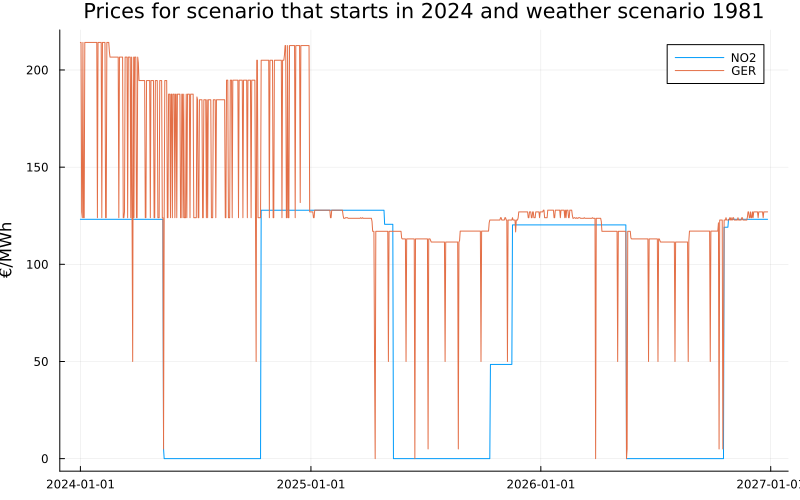

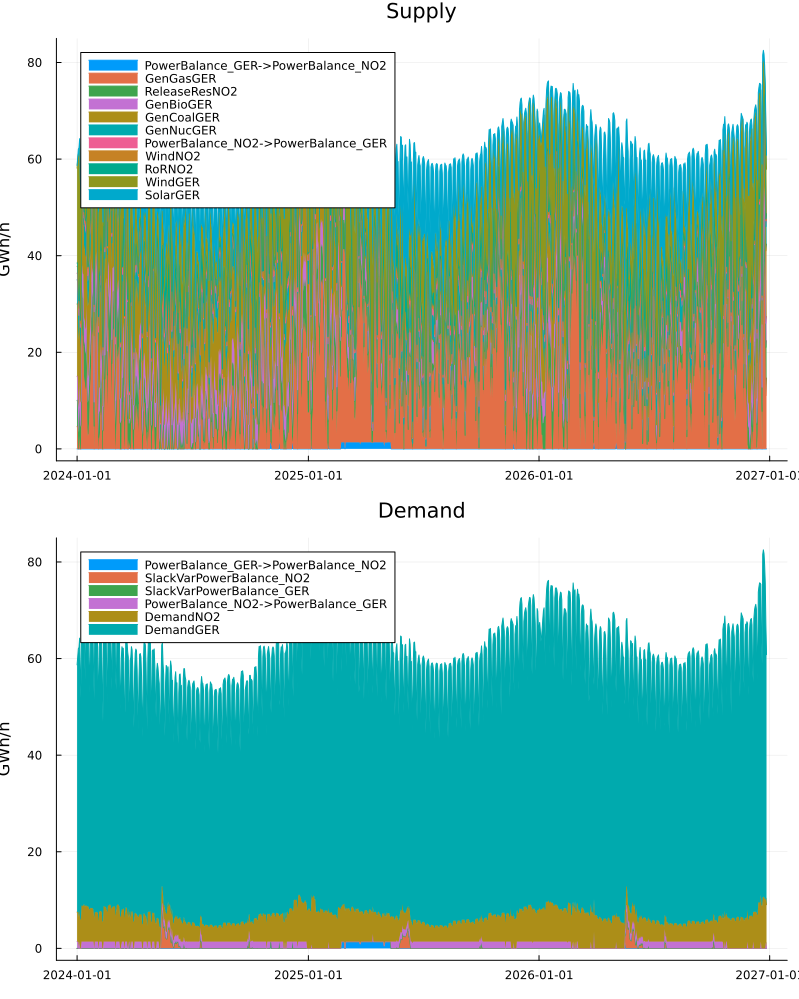

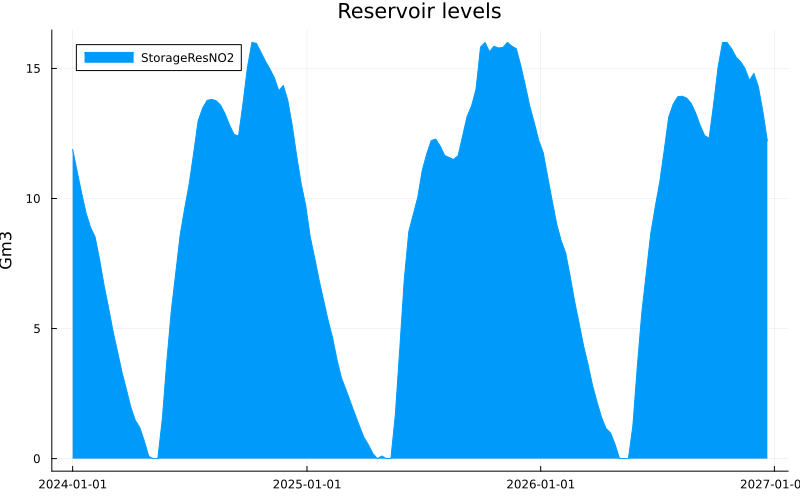

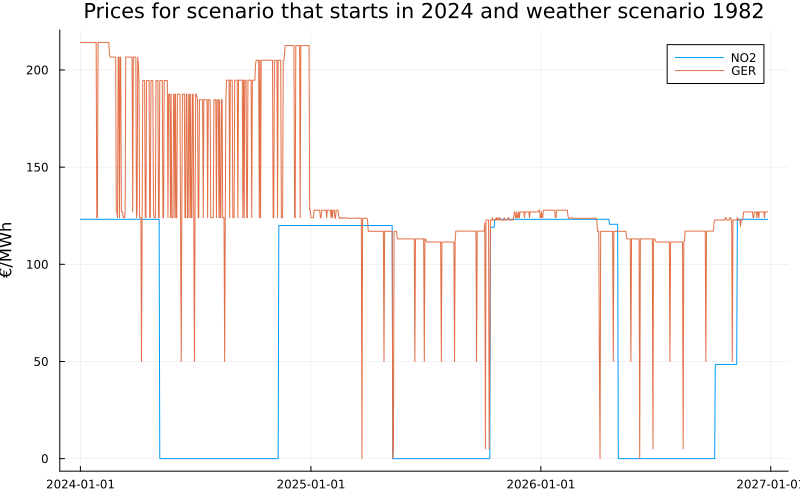

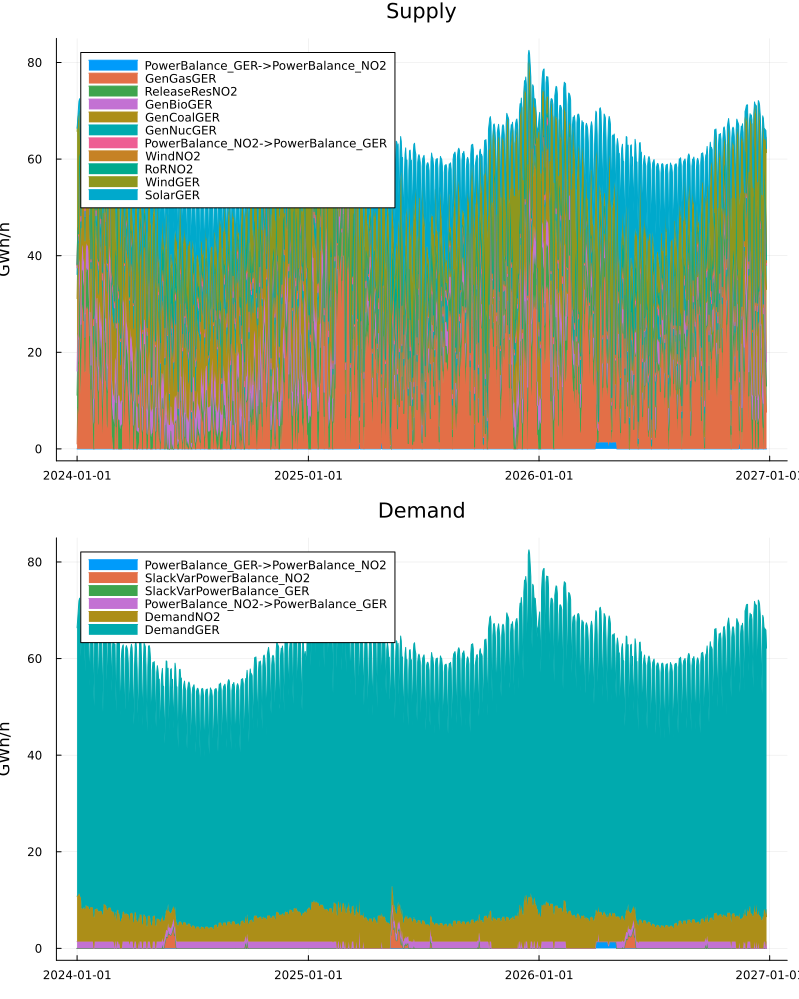

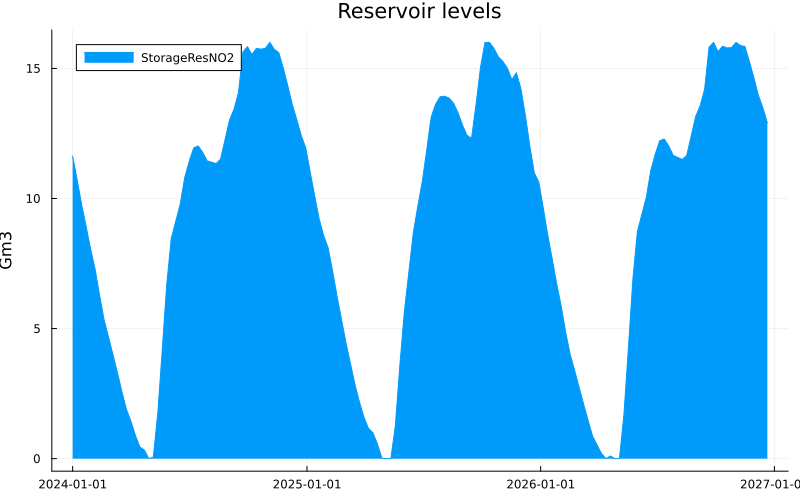

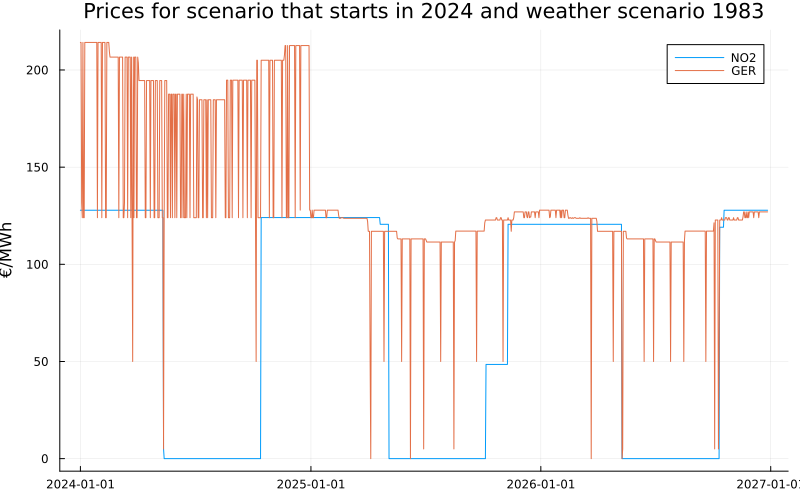

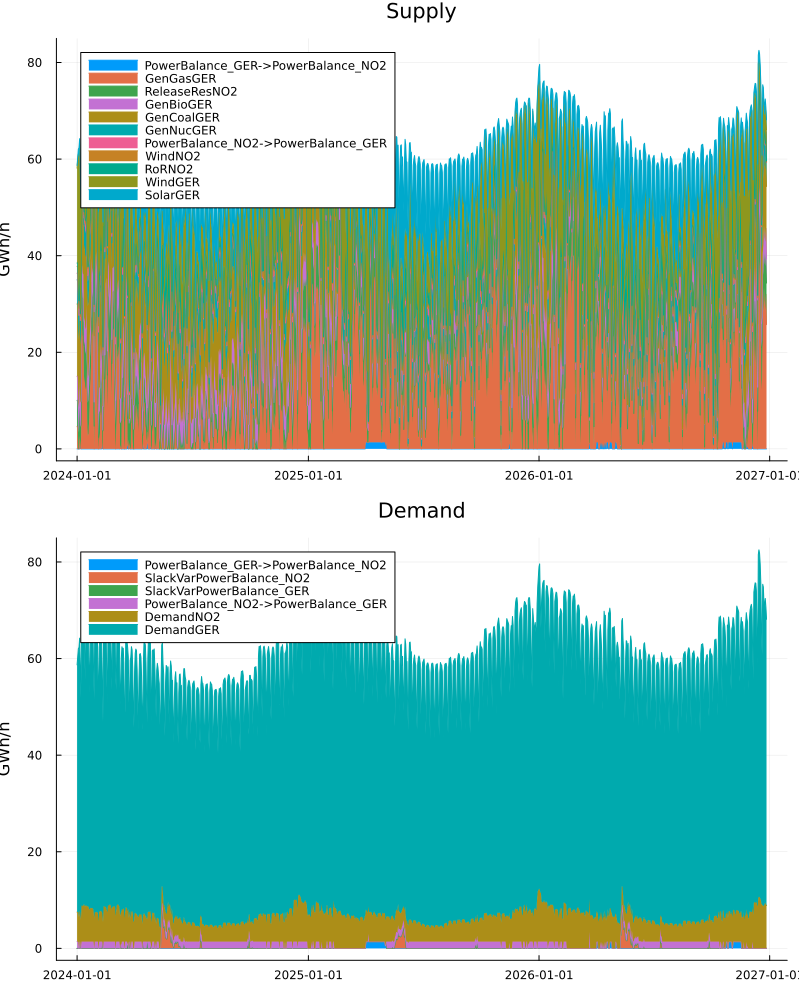

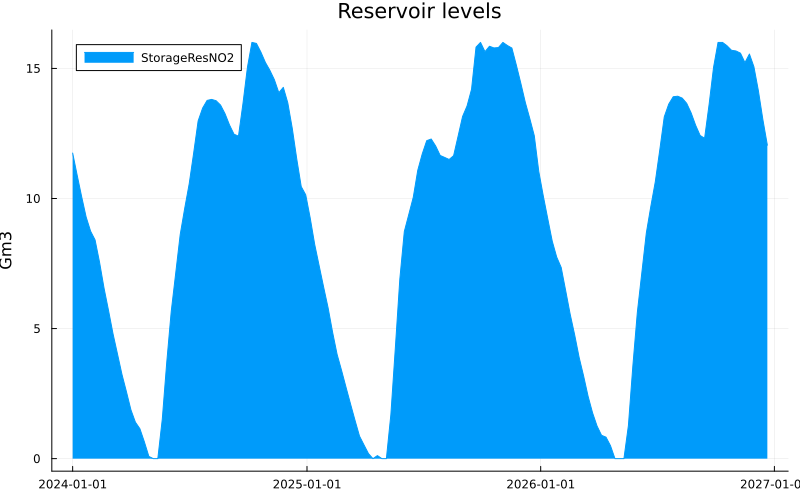

In [29]:
scenarios = getscenarios(2024; years=1981:1983)

runscenarios(scenarios, modelobjects)

# alternative for only seeing results from one price area
# resultobjects = getpowerobjects(modelobjects,["NO2"])
# runscenarios(scenarios, modelobjects, resultobjects) 